# Financial Trading with Python, 2nd Edition
Cordell L. Tanny, CFA, FRM, FDP

## Chapter 4: Exploratory Data Analysis
### Notebook 4.2: Correlation and Relationships Lab

Version: 1

Date of last revision: January 25, 2026

This notebook covers relationship analysis: scatter plots, correlation matrices, pair plots, and rolling correlations. We will also build the Range Plot, a custom visualization that condenses distribution information into a single comparative view.

**Important:** This notebook uses data files created in Notebook 4.1. If you saved the parquet files from that notebook, upload them to the Files section (left sidebar in Colab) **before running** this notebook. If the files are not found, the notebook will download fresh data automatically.

*Note and recommendation: Very often, you might want to experiment on your own as you go through this notebook. We recommend you save a copy of this notebook before you start adding cells or changing anything. This way you always have a pristine copy to go back to.*

---

## Setup

In [ ]:
# Install packages if needed (uncomment if running in Colab)
# !pip install yfinance seaborn plotly --quiet

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from scipy import stats
import os
import warnings

# Display settings
pd.set_option('display.max_rows', 20)
pd.set_option('display.max_columns', 12)
pd.set_option('display.float_format', '{:.4f}'.format)
warnings.filterwarnings('ignore')

# Plot settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print(f"pandas version: {pd.__version__}")
print(f"numpy version: {np.__version__}")
print(f"seaborn version: {sns.__version__}")

pandas version: 2.2.2
numpy version: 2.0.2
seaborn version: 0.13.2


---

## Section 1: Load Data

We attempt to load the parquet files created in Notebook 4.1. If they are not found, we download fresh data.

**If you saved files from Notebook 4.1:** Upload `broad_asset_prices.parquet` and `broad_asset_returns.parquet` to the Files section (left sidebar) **before** running the cell below.

In [2]:
# Check if parquet files exist, otherwise download fresh data
if os.path.exists('broad_asset_prices.parquet') and os.path.exists('broad_asset_returns.parquet'):
    df_prices = pd.read_parquet('broad_asset_prices.parquet')
    df_returns = pd.read_parquet('broad_asset_returns.parquet')
    print("Loaded data from parquet files.")
else:
    print("Parquet files not found. Downloading fresh data...")

    # Configuration
    tickers = ['SPY', 'IWM', 'EFA', 'EEM', 'TLT', 'GOVT', 'LQD', 'IGOV', 'IBND', 'GLD']
    start_date = '2012-01-01'
    end_date = '2025-12-31'

    # Download
    df_daily = yf.download(tickers, start=start_date, end=end_date, auto_adjust=False, progress=True)
    df_prices_daily = df_daily['Adj Close'].copy()

    # Align to common start date
    first_valid = df_prices_daily.apply(lambda x: x.first_valid_index())
    common_start = first_valid.max()
    df_prices_daily = df_prices_daily.loc[common_start:].copy()

    # Resample to monthly
    df_prices = df_prices_daily.resample('ME').last()
    df_returns = df_prices.pct_change().dropna()

    print("Download complete.")

print(f"\nPrices shape: {df_prices.shape}")
print(f"Returns shape: {df_returns.shape}")
print(f"Date range: {df_returns.index[0].strftime('%Y-%m-%d')} to {df_returns.index[-1].strftime('%Y-%m-%d')}")

Loaded data from parquet files.

Prices shape: (167, 10)
Returns shape: (166, 10)
Date range: 2012-03-31 to 2025-12-31


In [3]:
# Quick verification
df_returns.head()

Ticker,EEM,EFA,GLD,GOVT,IBND,IGOV,IWM,LQD,SPY,TLT
Date,,,,,,,,,,
2012-03-31,-0.0311,0.0042,-0.0132,-0.0077,0.0140,-0.0111,0.0248,-0.0142,0.0322,-0.0424
2012-04-30,-0.0170,-0.0208,-0.0015,0.0128,-0.0041,0.0127,-0.0162,0.0108,-0.0067,0.0483
2012-05-31,-0.1071,-0.1114,-0.0634,0.0201,-0.0659,-0.0338,-0.0658,0.0076,-0.0601,0.0903
2012-06-30,0.0504,0.0704,0.0235,-0.0052,0.0256,0.0097,0.0505,0.0087,0.0406,-0.0168
2012-07-31,-0.0003,0.0008,0.0084,0.0099,0.0019,0.0105,-0.0152,0.0348,0.0118,0.0382


---

## Section 2: Scatter Plots

Scatter plots show the relationship between two variables. Each point represents one observation (in our case, one month), with its x-coordinate from one asset and y-coordinate from another.

**When to use scatter plots:**
- To visualize the relationship between two assets
- To identify correlation direction (positive, negative, none)
- To spot outliers or unusual observations
- To check if a linear model is appropriate

**Key information you extract:**
- Direction of relationship (upward slope = positive, downward = negative)
- Strength of relationship (tight cluster = strong, dispersed = weak)
- Outliers that might distort correlation calculations

### 2.1 Basic Scatter Plot

Let us examine the relationship between SPY (US equities) and TLT (long-term bonds). Historically, these have exhibited negative correlation during flight-to-safety episodes.

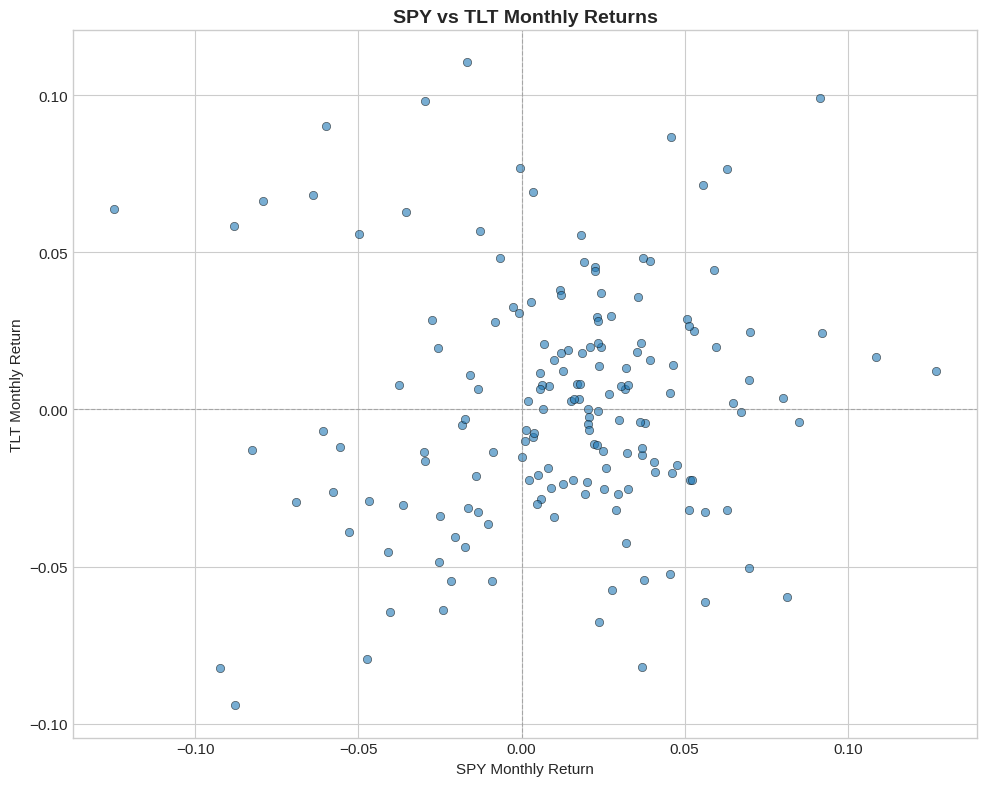

In [4]:
# Basic scatter plot
fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(df_returns['SPY'], df_returns['TLT'], alpha=0.6, edgecolor='black', linewidth=0.5)

ax.set_title('SPY vs TLT Monthly Returns', fontsize=14, fontweight='bold')
ax.set_xlabel('SPY Monthly Return')
ax.set_ylabel('TLT Monthly Return')
ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax.axvline(x=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

plt.tight_layout()
plt.show()

The scatter shows a slight negative relationship: when SPY is up, TLT tends to be down, and vice versa. The dashed lines at zero divide the plot into quadrants, making it easy to see which quadrant most points fall into.

Points in the upper-left (SPY down, TLT up) and lower-right (SPY up, TLT down) quadrants indicate negative correlation.

### 2.2 Scatter Plot with Regression Line

Adding a regression line quantifies the relationship and makes the trend clearer. We can also display the correlation coefficient.

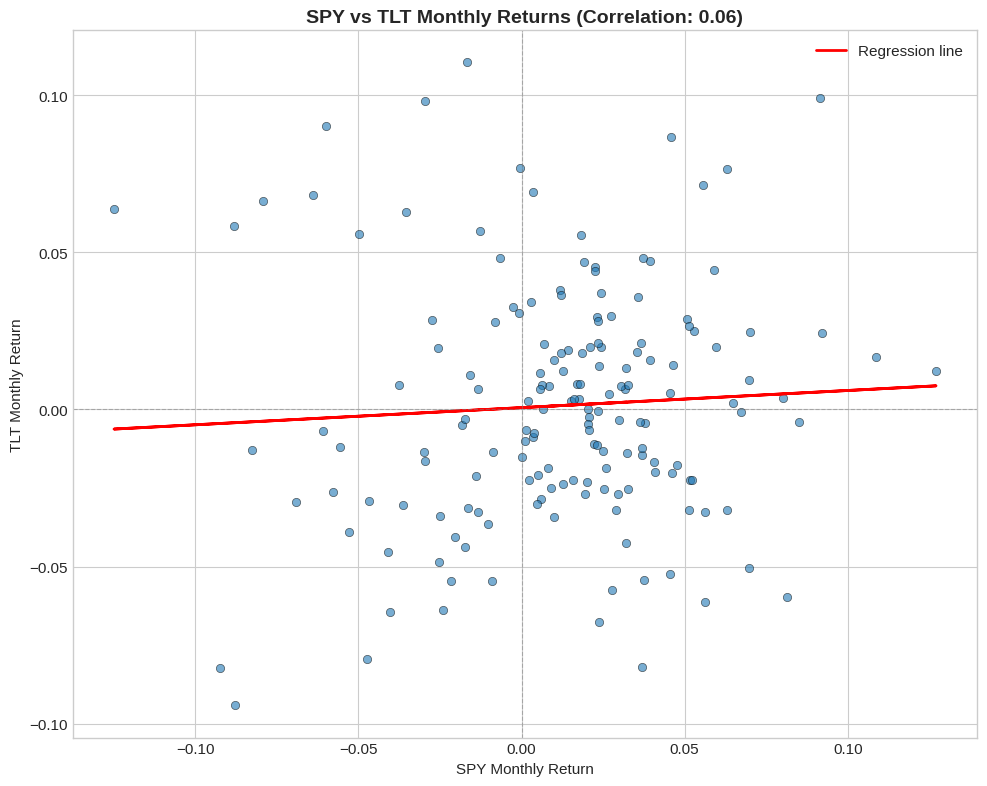

In [5]:
# Scatter with regression line
fig, ax = plt.subplots(figsize=(10, 8))

x = df_returns['SPY']
y = df_returns['TLT']

# Scatter points
ax.scatter(x, y, alpha=0.6, edgecolor='black', linewidth=0.5)

# Regression line
slope, intercept = np.polyfit(x, y, 1)
ax.plot(x, slope * x + intercept, color='red', linewidth=2, label=f'Regression line')

# Calculate correlation
corr = x.corr(y)

ax.set_title(f'SPY vs TLT Monthly Returns (Correlation: {corr:.2f})', fontsize=14, fontweight='bold')
ax.set_xlabel('SPY Monthly Return')
ax.set_ylabel('TLT Monthly Return')
ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax.axvline(x=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax.legend()

plt.tight_layout()
plt.show()

The correlation of 0.06 indicates virtually no linear relationship between SPY and TLT over this period. The regression line is nearly flat.
This result might surprise you: conventional wisdom says stocks and bonds are negatively correlated. However, the relationship depends heavily on the time period. The 2012-2025 period includes the 2022 episode when both stocks and bonds fell together during aggressive Fed rate hikes, which pushed the overall correlation toward zero.
This highlights an important lesson: historical correlation is not stable. A diversification strategy based on assumed negative stock-bond correlation can fail when the relationship shifts.

### 2.3 Seaborn regplot and jointplot

Seaborn provides functions that add statistical context to scatter plots automatically.

**`regplot` (Regression Plot):**

- Adds a regression line with a 95% confidence interval shaded around it
- The confidence interval shows the uncertainty in the regression estimate
- A narrow band means the relationship is estimated precisely; a wide band means more uncertainty
- Useful when you want to assess not just the trend but also how confident you should be in it

**`jointplot`:**

- Combines a scatter plot with marginal distributions (histograms or KDE) on the axes
- Shows the relationship between two variables (center) and each variable's distribution (margins) in one view
- Helps you see if outliers in the scatter are also outliers in the individual distributions
- Useful when you want a complete picture of two variables without creating multiple separate plots

**When to use these instead of basic scatter:**

- Use regplot when you want to visualize regression uncertainty, not just the line
- Use jointplot when you want to see both the relationship and the individual distributions together
- For quick exploratory analysis, these save time by combining multiple views into one

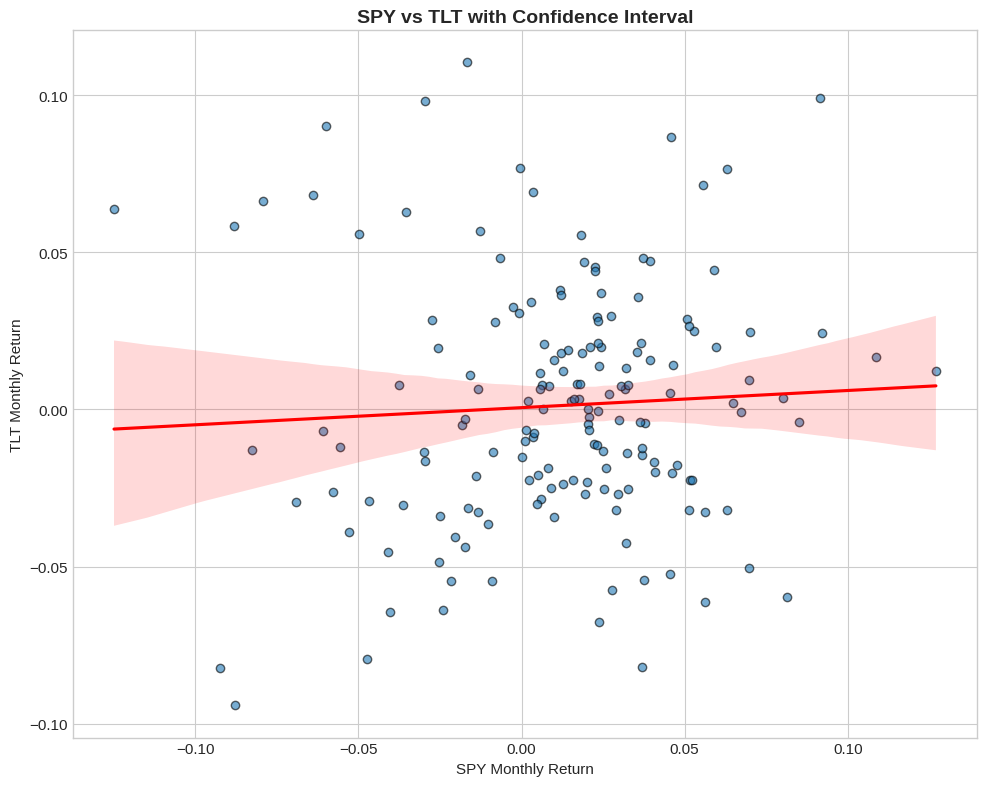

In [8]:
# Seaborn regplot - scatter with regression line and confidence interval
fig, ax = plt.subplots(figsize=(10, 8))

sns.regplot(x=df_returns['SPY'], y=df_returns['TLT'], ax=ax,
            scatter_kws={'alpha': 0.6, 'edgecolor': 'black'},
            line_kws={'color': 'red'})

ax.set_title('SPY vs TLT with Confidence Interval', fontsize=14, fontweight='bold')
ax.set_xlabel('SPY Monthly Return')
ax.set_ylabel('TLT Monthly Return')

plt.tight_layout()
plt.show()

The shaded area around the regression line shows the 95% confidence interval for the regression estimate. A wider band indicates more uncertainty in the relationship.

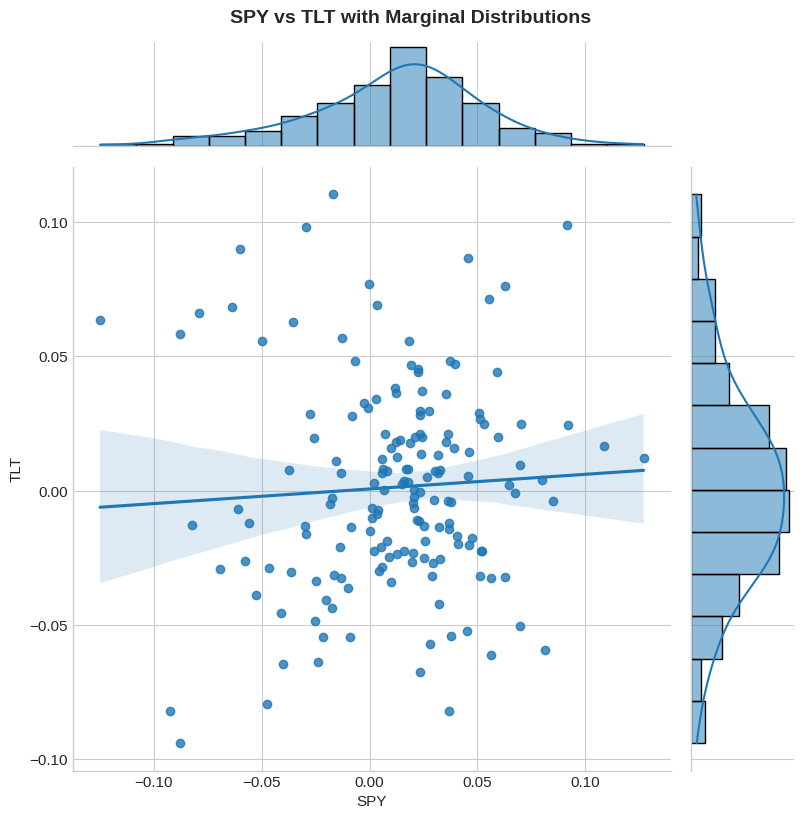

In [9]:
# Seaborn jointplot - scatter with marginal distributions
g = sns.jointplot(x=df_returns['SPY'], y=df_returns['TLT'], kind='reg', height=8)
g.figure.suptitle('SPY vs TLT with Marginal Distributions', y=1.02, fontsize=14, fontweight='bold')
plt.show()

The jointplot adds histograms on the margins showing the individual distributions of each variable. This combines relationship analysis (center) with distribution analysis (margins) in one view.

---

## Section 3: Correlation Analysis

Correlation measures the linear relationship between two variables on a scale from -1 to +1. When you have many assets, examining all pairwise correlations at once requires a correlation matrix.

**When to use correlation analysis:**
- To understand diversification potential in a portfolio
- To identify assets that move together (or opposite)
- To select hedging instruments
- To detect regime changes when correlations shift

**Key information you extract:**
- Which assets provide diversification (low or negative correlation)
- Which assets are redundant (high correlation)
- Clusters of related assets

### 3.1 Computing the Correlation Matrix

Pandas makes this simple with the `.corr()` method.

In [10]:
# Compute correlation matrix
corr_matrix = df_returns.corr()

# Display with formatting
corr_matrix.round(2)

Ticker,EEM,EFA,GLD,GOVT,IBND,IGOV,IWM,LQD,SPY,TLT
Ticker,,,,,,,,,,
EEM,1.0000,0.8100,0.3100,0.1400,0.6900,0.5900,0.6000,0.5400,0.6700,0.1100
EFA,0.8100,1.0000,0.1900,0.1300,0.7300,0.6000,0.7400,0.5700,0.8300,0.0700
GLD,0.3100,0.1900,1.0000,0.3400,0.4400,0.5100,-0.0100,0.3700,0.0800,0.3100
GOVT,0.1400,0.1300,0.3400,1.0000,0.3700,0.6200,-0.0100,0.7500,0.0900,0.9100
IBND,0.6900,0.7300,0.4400,0.3700,1.0000,0.9100,0.4500,0.6700,0.5500,0.2900
IGOV,0.5900,0.6000,0.5100,0.6200,0.9100,1.0000,0.3400,0.7600,0.4300,0.5500
IWM,0.6000,0.7400,-0.0100,-0.0100,0.4500,0.3400,1.0000,0.4400,0.8600,-0.0200
LQD,0.5400,0.5700,0.3700,0.7500,0.6700,0.7600,0.4400,1.0000,0.5300,0.7400
SPY,0.6700,0.8300,0.0800,0.0900,0.5500,0.4300,0.8600,0.5300,1.0000,0.0600


The matrix is symmetric (correlation of A with B equals correlation of B with A) and has 1.0 on the diagonal (every asset is perfectly correlated with itself). Reading this table directly is tedious, so we visualize it as a heatmap.

### 3.2 Correlation Heatmap

A heatmap uses color to represent values, making patterns immediately visible.

**When to use:** When you want to quickly identify correlation patterns across many assets.

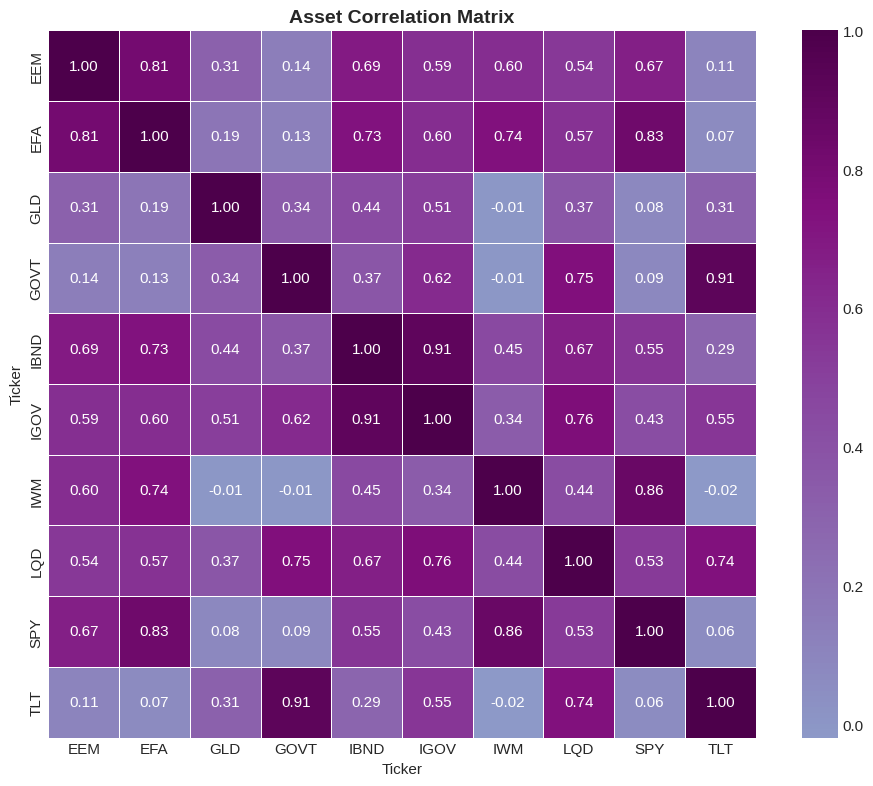

In [12]:
# Basic heatmap
fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='BuPu', center=0,
            square=True, linewidths=0.5, ax=ax)

ax.set_title('Asset Correlation Matrix', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

Reading the heatmap:

- Darker purple: Higher correlation (assets move together)
- Lighter shades: Lower correlation (weaker relationship)
- Near white: Close to zero correlation (no linear relationship)

The sequential colormap works well here since most asset correlations are positive. The intensity of the color immediately shows correlation strength.

Notice the cluster of equity assets (SPY, IWM, EFA, EEM) showing high positive correlation with each other (dark purple block). The bond cluster (TLT, GOVT, LQD) also shows positive correlation within the cluster.

GLD stands out with lighter colors against most assets, indicating it provides diversification benefit. The near-zero correlations between equities and TLT (0.06-0.11) confirm what we saw in the scatter plot.

### 3.3 Heatmap with Masked Upper Triangle

Since the correlation matrix is symmetric, we can mask the upper triangle to reduce redundancy and make the visualization cleaner.

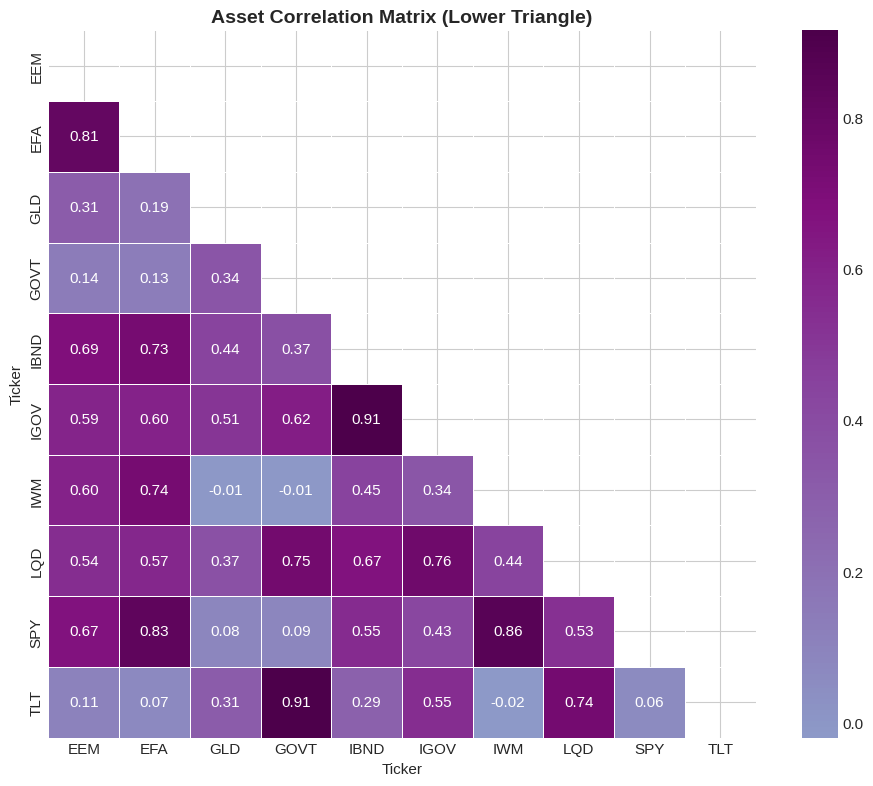

In [14]:
# Create mask for upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='BuPu', center=0,
            square=True, linewidths=0.5, ax=ax)

ax.set_title('Asset Correlation Matrix (Lower Triangle)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

This version shows only the unique correlation pairs, eliminating the redundant upper triangle and the trivial diagonal. The visual is cleaner and focuses attention on the meaningful relationships.

---

## Section 4: Pair Plots

A pair plot creates a matrix of scatter plots for all pairs of variables. The diagonal typically shows histograms or KDE plots for each individual variable.

**When to use:** When you want to see all pairwise relationships at once.

**Limitation:** Pair plots become unwieldy with more than 5-6 variables. For our 10-asset dataset, we will select a subset.

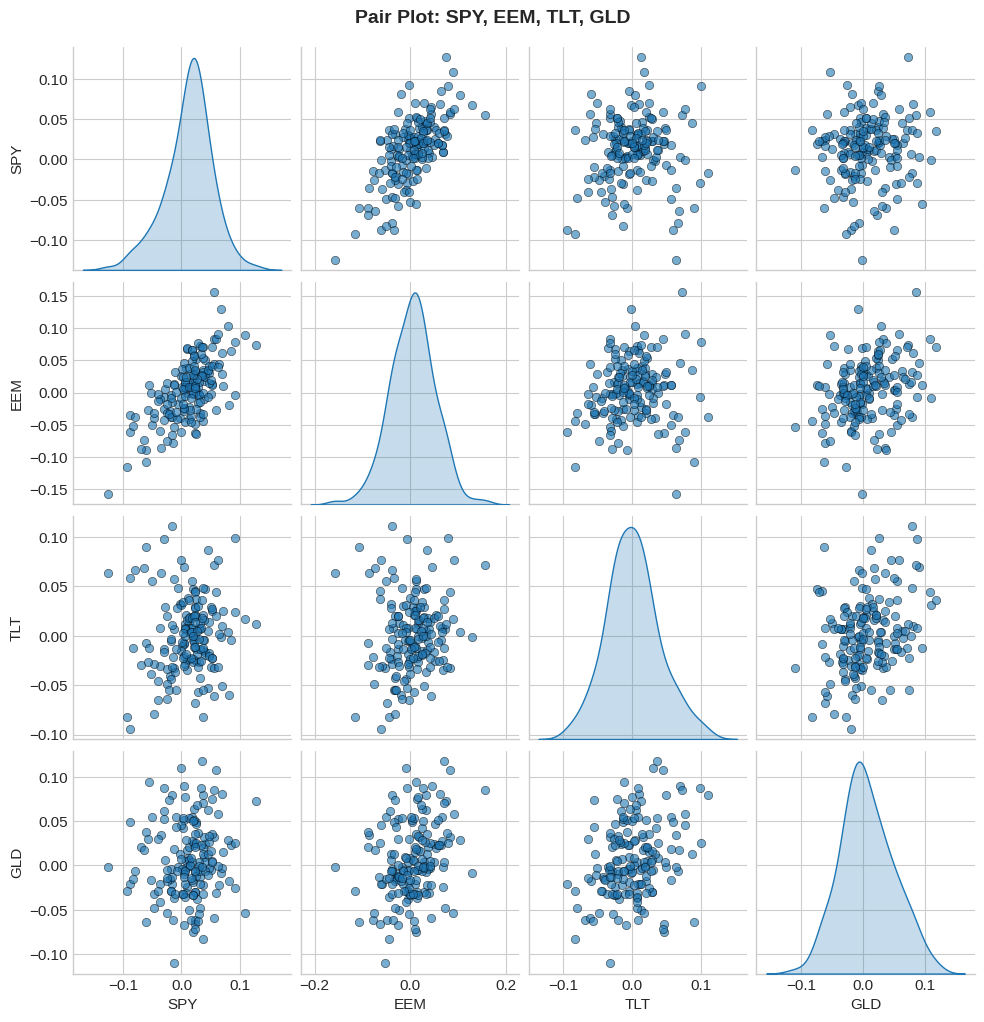

In [15]:
# Pair plot for a subset of assets
subset_tickers = ['SPY', 'EEM', 'TLT', 'GLD']

g = sns.pairplot(df_returns[subset_tickers], diag_kind='kde',
                 plot_kws={'alpha': 0.6, 'edgecolor': 'black', 'linewidth': 0.5})
g.figure.suptitle('Pair Plot: SPY, EEM, TLT, GLD', y=1.02, fontsize=14, fontweight='bold')
plt.show()

**Reading the pair plot:**
- **Diagonal:** Distribution of each individual asset (KDE curves)
- **Off-diagonal:** Scatter plot of the row variable vs. column variable

You can quickly scan for:
- Strong relationships (tight scatter patterns)
- Negative relationships (downward-sloping scatters)
- Outliers (isolated points)

The pair plot confirms what we saw in the correlation heatmap: TLT has negative correlation with equity assets, while GLD has near-zero correlation with most assets.

---

## Section 5: Rolling Correlation

Correlation is not constant over time. During market crises, correlations often spike as all risky assets fall together. Rolling correlation reveals how relationships evolve.

**When to use:**
- To assess stability of diversification benefits
- To identify regime changes
- To understand how relationships behave during stress periods

**Key insight:** If correlation between assets spikes during crises (when you need diversification most), the diversification benefit may be illusory.

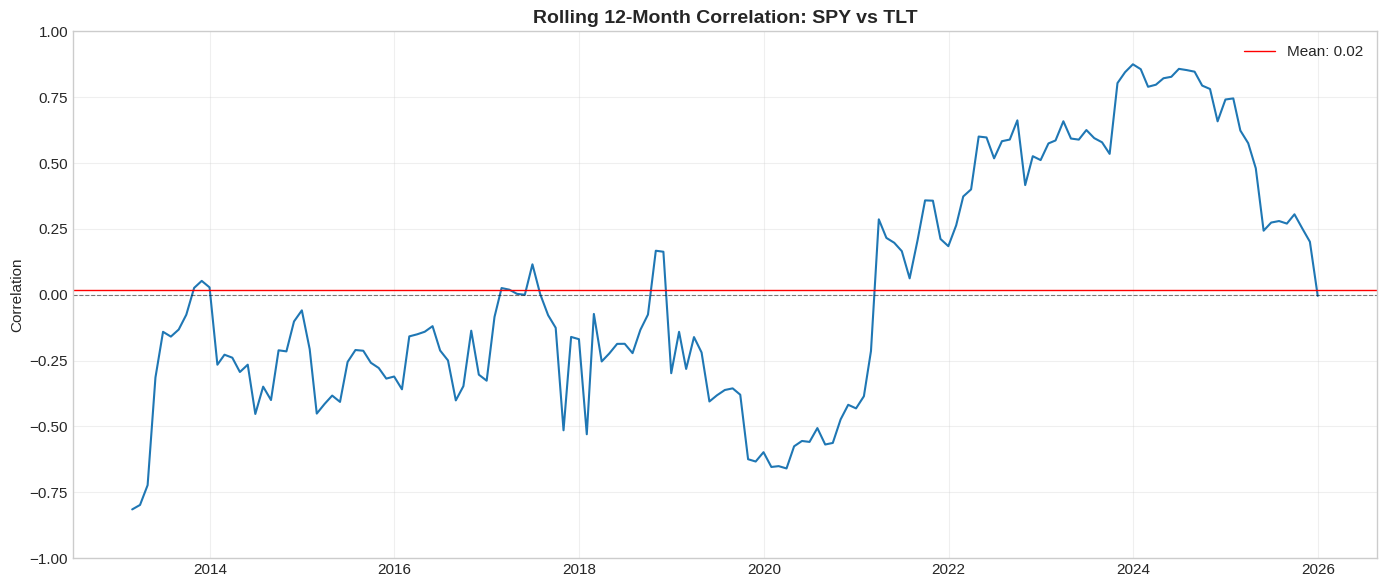

In [16]:
# Calculate 12-month rolling correlation between SPY and TLT
rolling_window = 12
rolling_corr = df_returns['SPY'].rolling(window=rolling_window).corr(df_returns['TLT'])

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(rolling_corr.index, rolling_corr, linewidth=1.5)
ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax.axhline(y=rolling_corr.mean(), color='red', linestyle='-', linewidth=1,
           label=f'Mean: {rolling_corr.mean():.2f}')

ax.set_title(f'Rolling {rolling_window}-Month Correlation: SPY vs TLT', fontsize=14, fontweight='bold')
ax.set_ylabel('Correlation')
ax.set_xlabel('')
ax.set_ylim(-1, 1)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The rolling correlation varies dramatically over time. The mean is essentially zero (0.02), but this average masks two distinct regimes:

**2012-2020**: Correlation was consistently negative, ranging from -0.8 to near zero. During this period, bonds provided the diversification benefit that traditional portfolio theory assumes.

**2021-present**: Correlation shifted sharply positive, reaching as high as 0.85 in 2023-2024. This coincides with the period of high inflation and aggressive Fed rate hikes, when both stocks and bonds fell together.

This chart illustrates a critical risk management lesson:

The diversification benefit of bonds is not guaranteed. The correlation regime can shift, and it often shifts at the worst possible time. Portfolios built on the assumption of negative stock-bond correlation experienced unexpected losses when both asset classes declined simultaneously in 2022.

Think about the implications for trading strategies designed to shift between bonds and equities: the expected diversification benefit may vanish precisely when you need it most.

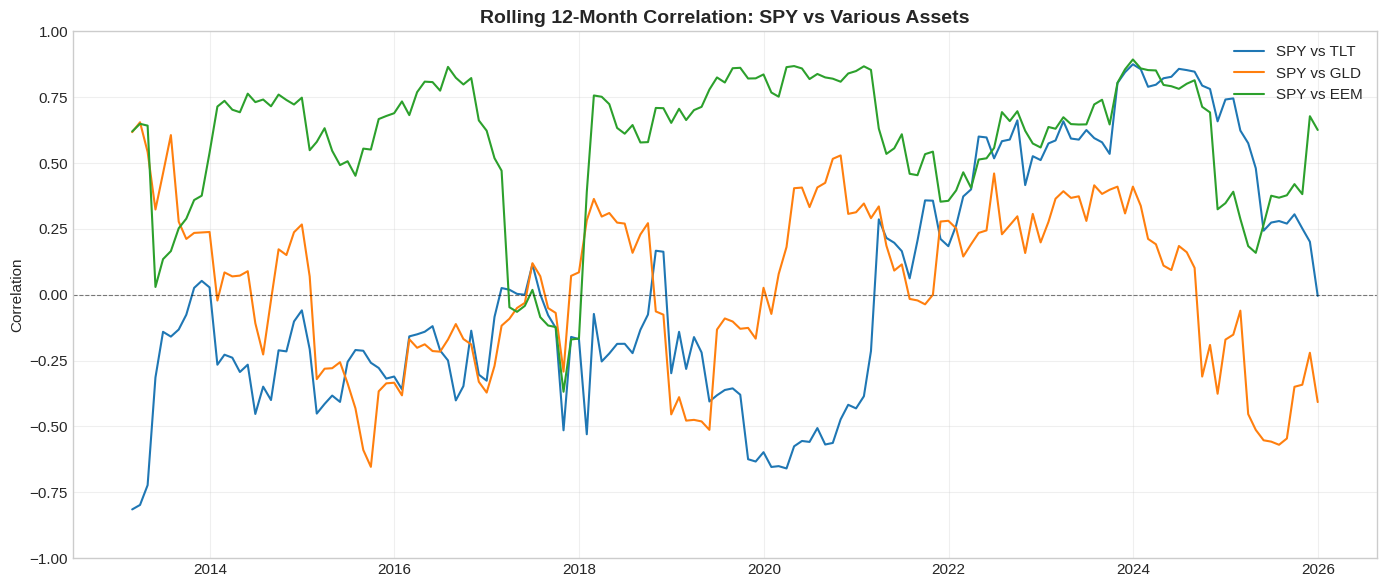

In [17]:
# Rolling correlation of SPY with multiple assets
fig, ax = plt.subplots(figsize=(14, 6))

compare_assets = ['TLT', 'GLD', 'EEM']
for asset in compare_assets:
    rolling = df_returns['SPY'].rolling(window=rolling_window).corr(df_returns[asset])
    ax.plot(rolling.index, rolling, linewidth=1.5, label=f'SPY vs {asset}')

ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_title(f'Rolling {rolling_window}-Month Correlation: SPY vs Various Assets', fontsize=14, fontweight='bold')
ax.set_ylabel('Correlation')
ax.set_xlabel('')
ax.set_ylim(-1, 1)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Comparing multiple rolling correlations reveals which assets provide more stable diversification:
- **SPY vs EEM:** Consistently high positive correlation (limited diversification)
- **SPY vs TLT:** Variable, sometimes negative (conditional diversification)
- **SPY vs GLD:** Fluctuates around zero (uncorrelated, good diversifier)

---

## Section 6: The Range Plot

The Range Plot is an original visualization designed specifically for this book. You will not find it in matplotlib, seaborn, or any charting library because we built it from scratch to solve a specific problem: how do you compare distributions across many assets while also showing where we are right now?

Standard distribution plots force tradeoffs. A histogram shows one asset's distribution but comparing ten histograms side by side is overwhelming. A box plot compares distributions but hides the tails. Summary statistics give you numbers but no visual intuition.

The Range Plot combines everything into a single view:

- Full historical range (minimum to maximum) so you see the complete picture
- Tail regions (5th and 95th percentiles) so you can identify when values are in outlier territory
- Mean so you have a reference point for "normal"
- Current value so you can instantly see where today sits relative to history

**The result:** one chart that answers multiple questions simultaneously. Which assets are most volatile? Where does the latest reading sit in historical context? Is the current value an outlier or typical? Are we near historical extremes?

This demonstrates a broader point about Python: when existing tools do not give you what you need, you can build exactly what you want.

### 6.1 Range Plot with Matplotlib

We build the Range Plot using horizontal bars for ranges and scatter points for mean and current values.

In [18]:
def range_plot(df, title='Range Plot', x_axis_label='Value'):
    """
    Create a range plot showing min, max, percentiles, mean, and current value.

    Parameters:
    df (pd.DataFrame): DataFrame with assets as columns
    title (str): Plot title
    x_axis_label (str): Label for x-axis

    Returns:
    fig, ax: Matplotlib figure and axes objects
    """
    # Calculate statistics
    min_val = df.min()
    max_val = df.max()
    perc5 = df.quantile(0.05)
    perc95 = df.quantile(0.95)
    mean_val = df.mean()
    current = df.iloc[-1]

    # Sort by mean for better visualization
    sort_order = mean_val.sort_values().index

    fig, ax = plt.subplots(figsize=(12, 8))

    y_positions = range(len(sort_order))

    for i, asset in enumerate(sort_order):
        # Full range bar (min to max) - light color
        ax.barh(i, max_val[asset] - min_val[asset], left=min_val[asset],
                height=0.6, color='lightblue', edgecolor='black', linewidth=0.5)

        # Tail regions (below 5th and above 95th percentile) - darker color
        ax.barh(i, perc5[asset] - min_val[asset], left=min_val[asset],
                height=0.6, color='steelblue', alpha=0.7)
        ax.barh(i, max_val[asset] - perc95[asset], left=perc95[asset],
                height=0.6, color='steelblue', alpha=0.7)

        # Mean marker
        ax.scatter(mean_val[asset], i, color='red', s=100, zorder=5, marker='o')

        # Current value marker
        ax.scatter(current[asset], i, color='green', s=100, zorder=5, marker='D')

    # Labels
    ax.set_yticks(y_positions)
    ax.set_yticklabels(sort_order)
    ax.set_xlabel(x_axis_label)
    ax.set_title(title, fontsize=14, fontweight='bold')

    # Legend
    from matplotlib.patches import Patch
    from matplotlib.lines import Line2D
    legend_elements = [
        Patch(facecolor='lightblue', edgecolor='black', label='Full Range (Min to Max)'),
        Patch(facecolor='steelblue', alpha=0.7, label='Tail Regions (< 5th, > 95th percentile)'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=10, label='Mean'),
        Line2D([0], [0], marker='D', color='w', markerfacecolor='green', markersize=10, label='Current')
    ]
    ax.legend(handles=legend_elements, loc='lower right')

    ax.grid(True, axis='x', alpha=0.3)

    plt.tight_layout()
    return fig, ax

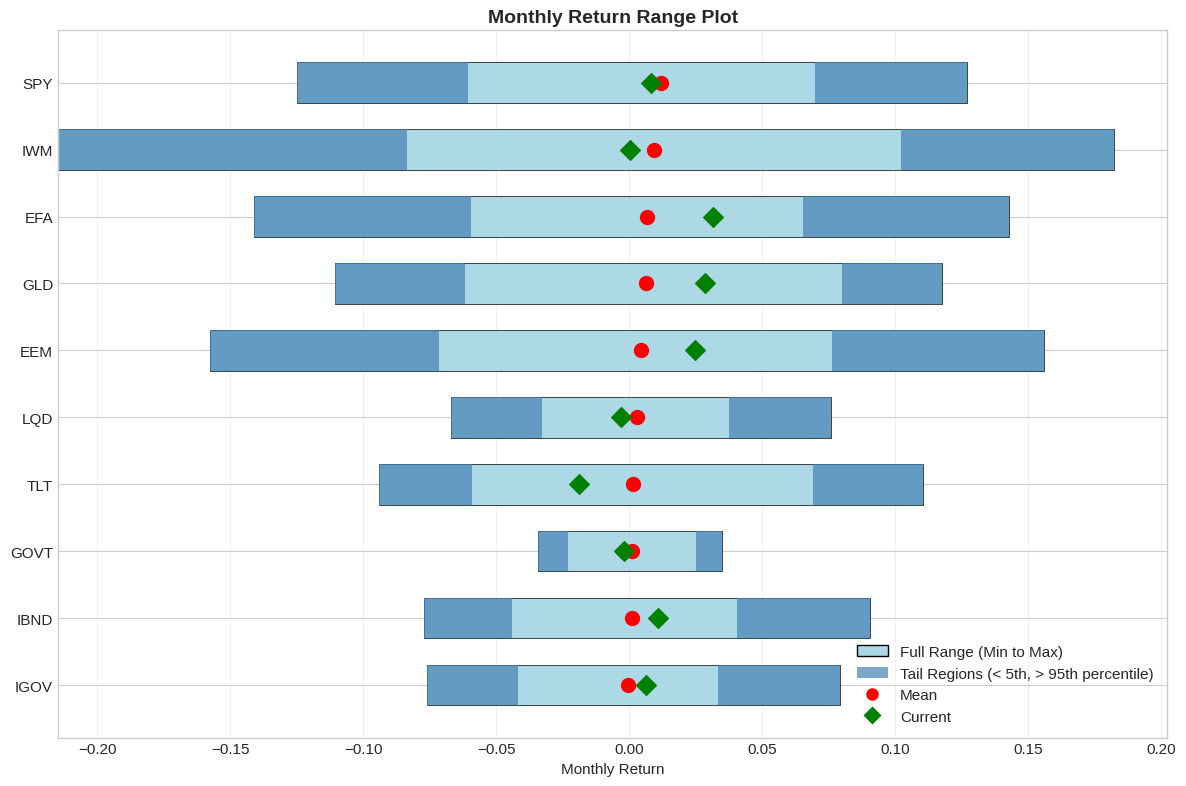

In [19]:
# Create range plot for monthly returns
fig, ax = range_plot(df_returns,
                     title='Monthly Return Range Plot',
                     x_axis_label='Monthly Return')
plt.show()

**Reading the Range Plot:**

- **Bar width:** Shows the full historical range (min to max)
- **Dark regions:** The 5% tails where extreme values occur
- **Red dot:** Mean value over the entire period
- **Green diamond:** Most recent value

**What to look for:**
- If the green diamond is in the dark regions, the current value is an historical extreme
- Wide bars indicate high volatility; narrow bars indicate stability
- Assets sorted by mean, so you can see which have highest/lowest average returns

These range plots are very effective when examining distributions over time, especially rolling correlations, asset class exposure, and economic indicators.

### 6.2 Interactive Range Plot with Plotly

An interactive version allows hovering over elements to see exact values.

In [20]:
def range_plot_plotly(df, title='Range Plot', x_axis_label='Value'):
    """
    Create an interactive range plot using Plotly.
    """
    # Calculate statistics
    min_val = df.min()
    max_val = df.max()
    perc5 = df.quantile(0.05)
    perc95 = df.quantile(0.95)
    mean_val = df.mean()
    current = df.iloc[-1]

    # Sort by mean
    sort_order = mean_val.sort_values().index.tolist()

    fig = go.Figure()

    for asset in sort_order:
        # Full range bar
        fig.add_trace(go.Bar(
            y=[asset],
            x=[max_val[asset] - min_val[asset]],
            base=min_val[asset],
            orientation='h',
            marker=dict(color='lightblue', line=dict(color='black', width=1)),
            name='Range',
            showlegend=(asset == sort_order[0]),
            hovertemplate=f'{asset}<br>Min: {min_val[asset]:.4f}<br>Max: {max_val[asset]:.4f}<extra></extra>'
        ))

        # Lower tail
        fig.add_trace(go.Bar(
            y=[asset],
            x=[perc5[asset] - min_val[asset]],
            base=min_val[asset],
            orientation='h',
            marker=dict(color='steelblue'),
            name='5th Percentile',
            showlegend=(asset == sort_order[0]),
            hovertemplate=f'{asset}<br>5th Percentile: {perc5[asset]:.4f}<extra></extra>'
        ))

        # Upper tail
        fig.add_trace(go.Bar(
            y=[asset],
            x=[max_val[asset] - perc95[asset]],
            base=perc95[asset],
            orientation='h',
            marker=dict(color='steelblue'),
            name='95th Percentile',
            showlegend=False,
            hovertemplate=f'{asset}<br>95th Percentile: {perc95[asset]:.4f}<extra></extra>'
        ))

    # Mean markers
    fig.add_trace(go.Scatter(
        x=[mean_val[asset] for asset in sort_order],
        y=sort_order,
        mode='markers',
        marker=dict(color='red', size=12, symbol='circle'),
        name='Mean',
        hovertemplate='%{y}<br>Mean: %{x:.4f}<extra></extra>'
    ))

    # Current markers
    fig.add_trace(go.Scatter(
        x=[current[asset] for asset in sort_order],
        y=sort_order,
        mode='markers',
        marker=dict(color='green', size=12, symbol='diamond'),
        name='Current',
        hovertemplate='%{y}<br>Current: %{x:.4f}<extra></extra>'
    ))

    fig.update_layout(
        title=title,
        xaxis_title=x_axis_label,
        barmode='overlay',
        height=500,
        legend=dict(orientation='h', yanchor='bottom', y=1.02)
    )

    return fig

In [21]:
# Interactive range plot
fig = range_plot_plotly(df_returns,
                        title='Monthly Return Range Plot (Interactive)',
                        x_axis_label='Monthly Return')
fig.show()

Hover over any element to see exact values. This makes it easy to identify specific numbers without cluttering the visualization.

---

## Section 7: Plotly Interactive Visualizations

We have already seen the interactive Range Plot. Here are a few more Plotly versions of the visualizations we created earlier.

In [22]:
# Interactive scatter plot
fig = px.scatter(df_returns, x='SPY', y='TLT',
                 title='SPY vs TLT Monthly Returns (Interactive)',
                 trendline='ols',
                 labels={'SPY': 'SPY Monthly Return', 'TLT': 'TLT Monthly Return'})

fig.add_hline(y=0, line_dash='dash', line_color='gray', opacity=0.5)
fig.add_vline(x=0, line_dash='dash', line_color='gray', opacity=0.5)

fig.show()

In [24]:
# Interactive correlation heatmap
fig = px.imshow(corr_matrix,
                text_auto='.2f',
                color_continuous_scale='BuPu',
                zmin=-1, zmax=1,
                title='Asset Correlation Matrix (Interactive)')

fig.update_layout(width=700, height=600)
fig.show()

---

## Notebook Summary

In this notebook, we covered relationship analysis techniques:

**Scatter Plots (Section 2):**
- Basic scatter for visualizing two-variable relationships
- Adding regression lines to quantify trends
- Seaborn regplot and jointplot for enhanced analysis

**Correlation Analysis (Section 3):**
- Computing correlation matrices with pandas
- Visualizing correlations as heatmaps
- Masking redundant information

**Pair Plots (Section 4):**
- Visualizing all pairwise relationships at once
- Practical limits on number of variables

**Rolling Correlation (Section 5):**
- Time-varying correlation analysis
- Identifying regime changes and correlation instability

**Range Plot (Section 6):**
- Custom visualization for distribution comparison
- Both static (Matplotlib) and interactive (Plotly) versions

**Key takeaways:**
1. Correlation measures linear relationships; scatter plots reveal the full picture
2. Correlation is not constant - rolling analysis reveals regime changes
3. Custom visualizations like the Range Plot demonstrate Python's flexibility
4. Interactive plots aid exploration; static plots are better for final output

In the next notebook, we will apply these techniques to our volatility tail hedge use case data.

*Note: Please do not forget to download the parquet files from the Files section in this notebook if you created new ones. If you close this notebook, those files will be lost.*